This notebook demonstrates how to sample object-based crop type ground truth data using Google Street View and Sentinel-2 imagery. In this example, we use aggregated GSV point counts, along with cultivated extent from USDA Crop Sequence Boundary (CSB) and irrigation data from Landsat-based Irrigation Dataset (LANID) by Xie et al. (2021), to determine the number of GSV sampling points (metadata) required for each of the 17 crop types in the CropSight-US dataset at the Agricultural Statistics District (ASD) level.

For details on the modeling and ground-truthing components, specifically the UncertainFusionNet and fine-tuned SAM models, please see the CropSight workflow example here: [CropSight.ipynb](https://colab.research.google.com/drive/1yoTC0MrmTVOrDZNF7A7rNcK-XbthJ1Ub?usp=drive_link)

**Reference:**
- Liu, Y., Diao, C., Mei, W., & Zhang, C. (2024). CropSight: Towards a large-scale operational framework for object-based crop type ground truth retrieval using street view and PlanetScope satellite imagery. ISPRS Journal of Photogrammetry and Remote Sensing, 216, 66-89.
- Xie, Y., Gibbs, H. K., & Lark, T. J. (2021). Landsat-based Irrigation Dataset (LANID): 30 m resolution maps of irrigation distribution, frequency, and change for the US, 1997–2017. Earth System Science Data, 13(12), 5689-5710.

## Step 1: Data Preparation at ASD-level
An **Agricultural Statistics District**  (ASD) is defined as a contiguous group of counties having relatively similar agricultural characteristics. The ASD's used by NASS usually divide each state into as many as nine Agricultural Statistics Districts to make data comparison easier. Each district is more homogeneous with respect to agriculture than the state as a whole. More information and the ASD shapefiles are available at: https://www.nass.usda.gov/Research_and_Science/Cropland/sarsfaqs2.php (located at the bottom of the webpage); https://www.nass.usda.gov/Data_and_Statistics/County_Data_Files/Frequently_Asked_Questions/county_list.txt.

In [5]:
import pandas as pd
import geopandas as gpd
import numpy as np
import geemap
import os
import csv
import matplotlib.pyplot as plt
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")
# import rasterio
# from rasterstats import zonal_stats

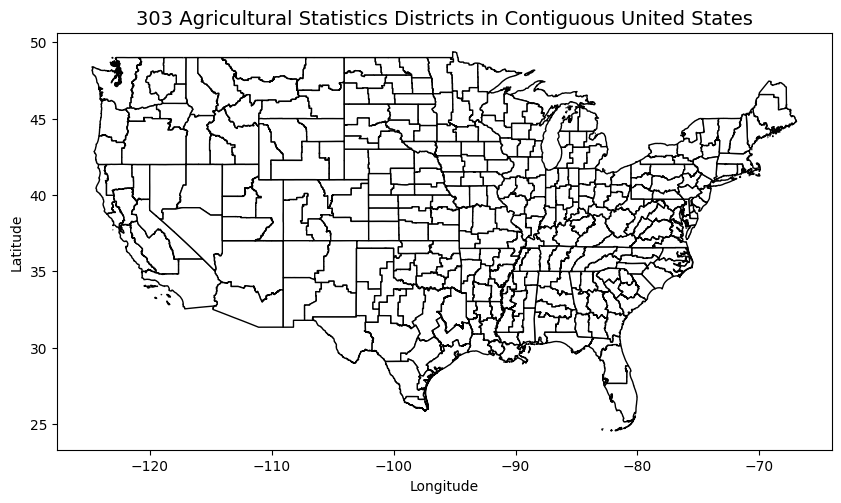

In [6]:
ASD = gpd.read_file('YOUR ASD SHAPEFILE PATH')

# Filter out states/territories outside the Contiguous US
# where `STATE` is 02 (ALASKA) or 15 (HAWAII) or 60 (AMERICAN SAMOA) or 66 (GUAM) or 72 (PUERTO RICO) or 78 (VIRGIN ISLANDS)
ASD = ASD[~ASD['STATE'].isin(["02", "15", "60", "66","72","78"])]

# Plot the ASD polygons (background)
ax = ASD.plot(edgecolor='black', facecolor='white', figsize=(10, 10))

# Add title and labels
plt.title(f'{len(ASD)} Agricultural Statistics Districts in Contiguous United States', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show the plot
plt.show()

In [7]:
# Load ASD-level field statistics from USDA CSB
CSB_grouped_ASD_CropType = pd.read_csv("YOUR ASD LEVEL CSB STATS")

This code generates a grid of choropleth maps showing field counts per ASD for each of 17 crop types by merging crop-level field data with ASD boundaries and visualizing them spatially.

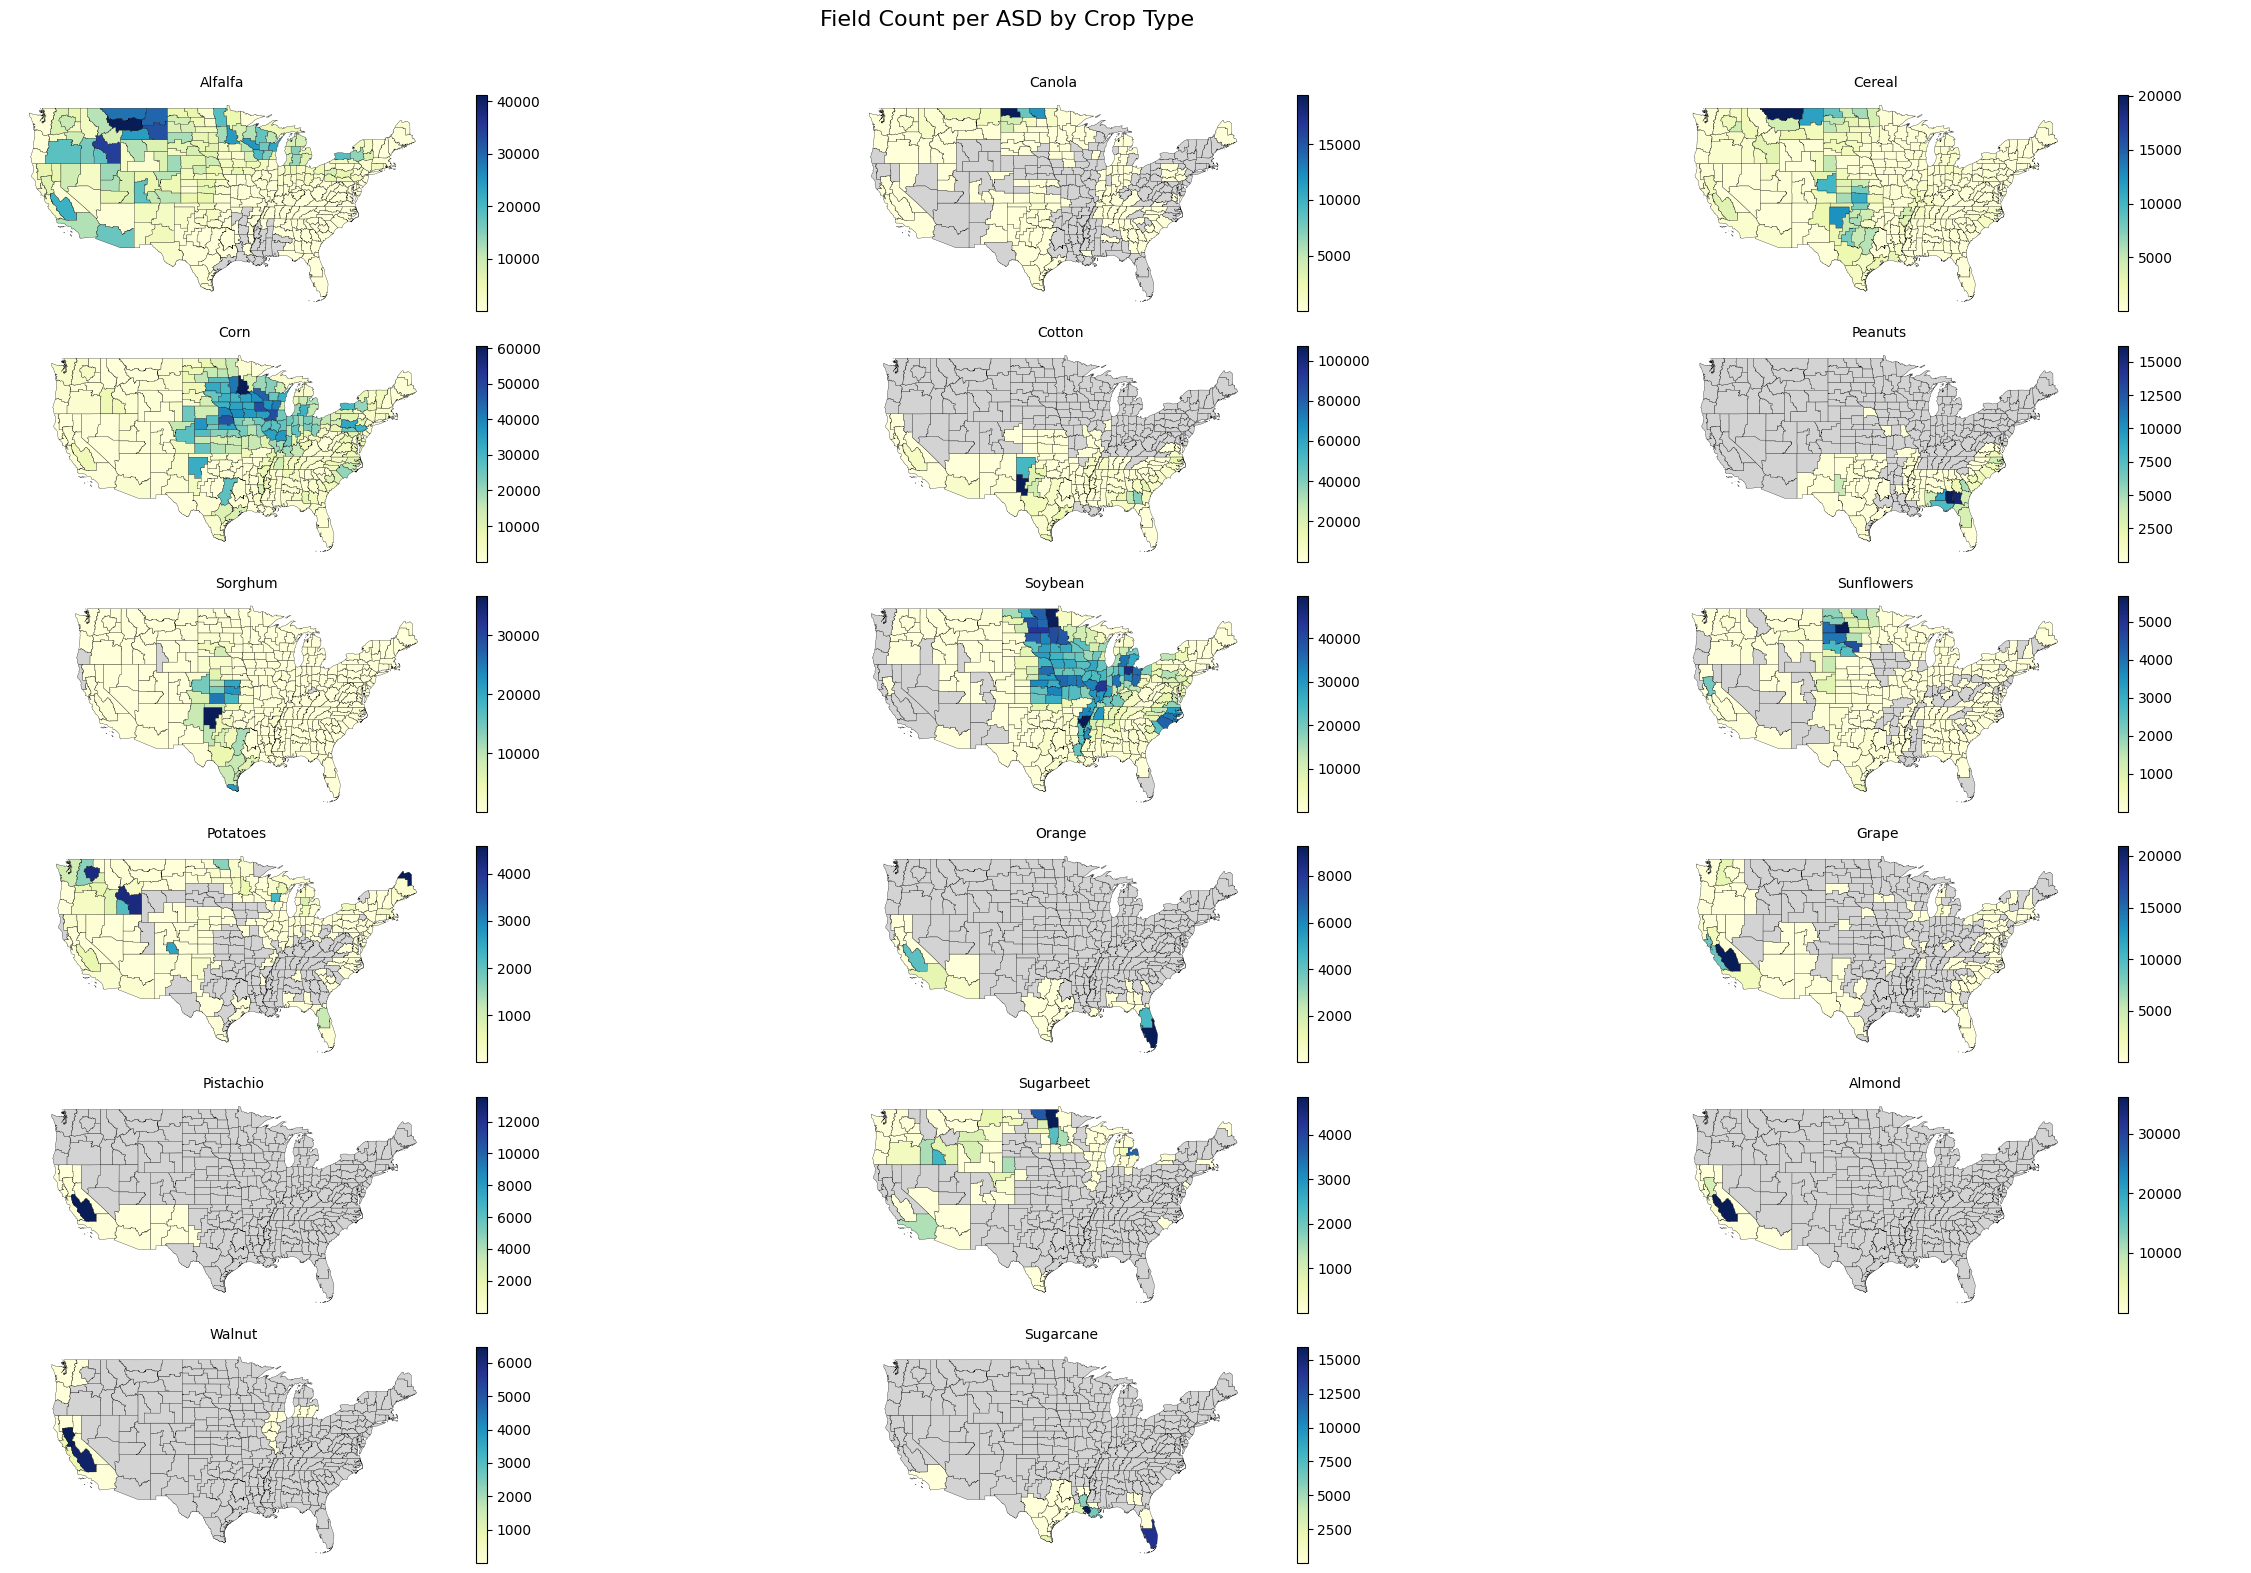

In [64]:
# Set up 6 by 3 subplot grid (will leave one empty since we have 17 crops)
fig, axes = plt.subplots(6, 3, figsize=(25, 16))
axes = axes.flatten()

# Loop over crop types
for i, crop in enumerate(CSB_grouped_ASD_CropType['Crop Type'].unique()):
    # Filter for current crop
    crop_df = CSB_grouped_ASD_CropType[CSB_grouped_ASD_CropType['Crop Type'] == crop]

    # Merge with ASD GeoDataFrame
    merged = ASD.merge(crop_df, left_on='STASD_N', right_on='STATEASD', how='left')

    # Plot choropleth
    merged.plot(column='Field Count', ax=axes[i], cmap='YlGnBu', legend=True,
                missing_kwds={"color": "lightgrey", "label": "No Data"},
                edgecolor='black', linewidth=0.2)

    axes[i].set_title(f'{crop}', fontsize=10)
    axes[i].axis('off')

# Hide the extra subplot if less than 20
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Field Count per ASD by Crop Type', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Step 2: Determine Sampling Target at the ASD-level

### Overview of GSV Candidates Availability at ASD level

In [9]:
import pandas as pd

gsv_candidates_all = pd.read_csv("YOUR GSV METADATA POINTS")

gsv_df_count_by_ASD = gsv_candidates_all.groupby(['STATEASD', 'label']).size().reset_index(name='GSV_Count')
# Group by Crop Type and calculate the sum of GSV_Count for each crop type
crop_summary = gsv_df_count_by_ASD.groupby('label')['GSV_Count'].sum().reset_index()

# Calculate the total GSV count across all crop types
total_gsv_count = crop_summary['GSV_Count'].sum()

# Calculate the percentage contribution of each crop type's GSV count to the total GSV count
crop_summary['Contribution_to_Total_GSV (%)'] = (crop_summary['GSV_Count'] / total_gsv_count) * 100

# Print the summary
print(crop_summary)
print("---------------------------------")

# Filter out crop types contributing less than 2% to the total GSV count
low_contribution_crops = crop_summary[crop_summary['Contribution_to_Total_GSV (%)'] < 2]

# For crops with less than 2% contribution, sampling will not be performed
print("Crop types with less than 2% contribution (no sampling):")
print(low_contribution_crops)
print(f"\nwith {low_contribution_crops['GSV_Count'].sum()} GSV Candidates ({round(low_contribution_crops['Contribution_to_Total_GSV (%)'].sum(),2)}%) of total GSV Candidates.")
print("---------------------------------")
# Sample only those crops with more than or equal to 2% contribution
high_contribution_crops = crop_summary[crop_summary['Contribution_to_Total_GSV (%)'] >= 2]

print("Crops that will be considered for sampling:")
print(high_contribution_crops)
print(f"\nwith {high_contribution_crops['GSV_Count'].sum()} GSV Candidates ({round(high_contribution_crops['Contribution_to_Total_GSV (%)'].sum(),2)}%) of total GSV Candidates.")

        label  GSV_Count  Contribution_to_Total_GSV (%)
0     alfalfa      12178                       6.295199
1      almond      11021                       5.697109
2      canola        520                       0.268805
3      cereal      15204                       7.859436
4        corn      78337                      40.494911
5      cotton       6478                       3.348686
6       grape       9378                       4.847789
7      orange       3412                       1.763772
8     peanuts       2136                       1.104167
9   pistachio        737                       0.380979
10   potatoes       1624                       0.839498
11    sorghum       2932                       1.515645
12    soybean      40153                      20.756375
13  sugarbeet       1181                       0.610497
14  sugarcane       5184                       2.679776
15  sunflower        359                       0.185579
16     walnut       2615                       1

In [10]:
current_crop = 'corn'

In [11]:
# Filters GSV candidates and field count data for the crop type sugarcane, and prepares ASD-level GSV counts and field counts for sampling.
before_sample_gsv = gsv_candidates_all[gsv_candidates_all['label'] == current_crop]

GSV_df_count_by_ASD = (gsv_candidates_all.groupby(['STATEASD', 'label']).size().reset_index(name='GSV Count').rename(columns={'label': 'Crop Type'}))
GSV_df_count_by_ASD = GSV_df_count_by_ASD[GSV_df_count_by_ASD['Crop Type'] == current_crop]

for_sample_field_by_ASD = CSB_grouped_ASD_CropType[CSB_grouped_ASD_CropType['Crop Type'] == current_crop.capitalize()]

### Assign Quantiles of ASD Based on Number of Fields

In [12]:
# Define the quantiles you want to use (e.g., 0.25, 0.5, 0.75 for quartiles)
quantiles = [0.25, 0.5, 0.75]

# Get the quantile values
quantile_values =for_sample_field_by_ASD['Field Count'].quantile(quantiles)

# Function to classify each value based on the quantile
def assign_quantile(value):
    if value <= quantile_values[0.25]:
        return 'Q1'
    elif value <= quantile_values[0.5]:
        return 'Q2'
    elif value <= quantile_values[0.75]:
        return 'Q3'
    else:
        return 'Q4'

# Apply the function to the DataFrame
for_sample_field_by_ASD['Quantile'] = for_sample_field_by_ASD['Field Count'].apply(assign_quantile)

In [13]:
gsv_db = GSV_df_count_by_ASD.merge(for_sample_field_by_ASD.drop(columns=['Crop Type','Unnamed: 0']), on=['STATEASD'], how='inner')

In [14]:
gsv_db

,STATEASD,Crop Type,GSV Count,Field Count,Quantile
0,110,corn,122,6466.333333,Q3
1,120,corn,18,3970.777778,Q2
2,130,corn,4,1259.000000,Q2
3,140,corn,6,1723.333333,Q2
4,150,corn,26,1915.666667,Q2
...,...,...,...,...,...
247,5570,corn,1333,37289.666667,Q4
248,5580,corn,1211,40546.222222,Q4
249,5590,corn,827,12390.333333,Q3
250,5610,corn,1,1350.111111,Q2


### ASD-Level GSV Sampling Based on Quantile-Adjusted Multipliers

In [15]:
avg_gsv_ASD = gsv_db['GSV Count'].mean()
print(f"ASD on average can contribute {round(avg_gsv_ASD,0)} {current_crop} GSV Points!")
# Define the multipliers for Q1, Q2, Q3, Q4
multipliers = {'Q1': 0.2, 'Q2': 0.4, 'Q3': 0.6, 'Q4': 0.8}

# Apply the logic to calculate 'Sample' based on GSV_Count and avg_gsv_ASD
def calculate_sample(row, avg_gsv_ASD, multipliers):
    if row['GSV Count'] <= avg_gsv_ASD:
        return row['GSV Count']
    else:
        # Assign the multiplier for each quantile (for example, use Q1 as multiplier)
        multiplier = multipliers[row['Quantile']]  # You can adjust this logic based on how you want to assign Q1, Q2, etc.
        return avg_gsv_ASD + (multiplier * (row['GSV Count'] - avg_gsv_ASD))

# Apply the function to create the 'Sample' column
gsv_db['Sample'] = gsv_db.apply(lambda row: calculate_sample(row, avg_gsv_ASD, multipliers), axis=1)

# Round the 'Sample' column up
gsv_db['Sample'] = np.ceil(gsv_db['Sample']).astype(int)

ASD on average can contribute 311.0 corn GSV Points!


In [16]:
gsv_db

,STATEASD,Crop Type,GSV Count,Field Count,Quantile,Sample
0,110,corn,122,6466.333333,Q3,122
1,120,corn,18,3970.777778,Q2,18
2,130,corn,4,1259.000000,Q2,4
3,140,corn,6,1723.333333,Q2,6
4,150,corn,26,1915.666667,Q2,26
...,...,...,...,...,...,...
247,5570,corn,1333,37289.666667,Q4,1129
248,5580,corn,1211,40546.222222,Q4,1031
249,5590,corn,827,12390.333333,Q3,621
250,5610,corn,1,1350.111111,Q2,1


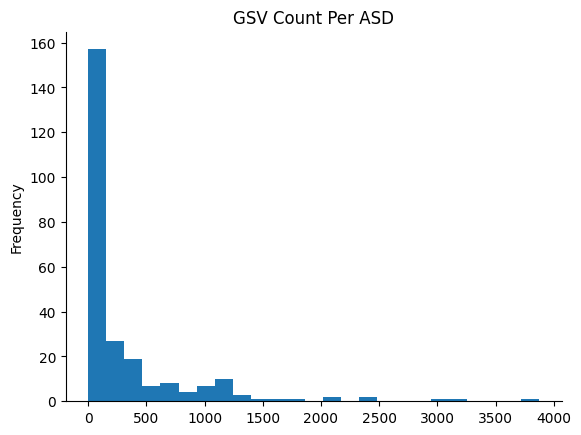

In [24]:
from matplotlib import pyplot as plt
gsv_db['GSV Count'].plot(kind='hist', bins=25, title='GSV Count Per ASD')
plt.gca().spines[['top', 'right',]].set_visible(False)

## Step 3: Sampling with Spatially Adapted Fishnet Method

In [17]:
import time
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
from osgeo import gdal, gdalconst, gdal_array, ogr, osr
import os
!pip install rasterstats
from rasterstats import zonal_stats, point_query
import matplotlib.pyplot as plt
import math
import random as rand
!pip install rasterio
import rasterio
from shapely import geometry
import json
from geopandas.tools import sjoin
from geographiclib.geodesic import Geodesic
import math
from pyproj import Proj, Transformer
import geopy
import geopy.distance
from pyproj import Geod
import geopandas as gpd
from shapely.geometry import Polygon
import warnings
warnings.filterwarnings("ignore")
# square_size = 0.00895

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 52.1 MB/s eta 0:00:00


In [13]:
# Functions originally designed for county-level sampling are now adapted for ASD-level sampling.
def fishnetMaker(square_size, county, fishnet_path, GSV_points):
    """
    Creates a square-grid fishnet over the given ASD (formerly county),
    intersects it with GSV points, and returns the number of grid cells
    containing at least one GSV point.

    Parameters:
    - square_size (float): The size of each square cell in degrees.
    - county (GeoDataFrame): GeoDataFrame representing the ASD boundary.
    - fishnet_path (str): File path to save the generated fishnet shapefile.
    - GSV_points (GeoDataFrame): GeoDataFrame of GSV sample points.

    Returns:
    - int: Number of grid cells (fishnet polygons) containing at least one GSV point.
    """
    if os.path.exists(fishnet_path):
        os.remove(fishnet_path)

    # Get the extent of the shapefile
    total_bounds = county.total_bounds
    # Get minX, minY, maxX, maxY
    minX, minY, maxX, maxY = total_bounds
    # Create a fishnet
    x, y = (minX, minY)
    geom_array = []

    # Polygon Size
    while y <= maxY:
        while x <= maxX:
            geom = geometry.Polygon([(x,y), (x, y+square_size), (x+square_size, y+square_size), (x+square_size, y), (x, y)])
            geom_array.append(geom)
            x += square_size
        x = minX
        y += square_size
    crs4 = 'GEOGCS["WGS 84",DATUM["WGS_1984",' \
       'SPHEROID["WGS 84",6378137,298.257223563,' \
       'AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],' \
       'PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],' \
       'UNIT["degree",0.01745329251994328,' \
       'AUTHORITY["EPSG","9122"]],' \
       'AUTHORITY["EPSG","4326"]]'     # Works
    fishnet = gpd.GeoDataFrame(geom_array, columns=['geometry']).set_crs(crs4)
    fishnet.to_file(fishnet_path)

    shape = gpd.read_file(fishnet_path)
    pointInPolys = sjoin(GSV_points, shape, how='left')
    # Remove rows where column 'index_right' has NaN values
    pointInPolys = pointInPolys.dropna(subset=['index_right'])
    polygonswithpoints = len(np.unique(pointInPolys.index_right))
    print(f"At grid size = {square_size}, we have polygons {polygonswithpoints} with points")
    return polygonswithpoints

def monotonic_closest(G, county, fishnet_path, GSV_points, target, integral):
    """
    Finds the closest fishnet cell size that results in approximately the
    target number of grid cells containing GSV points, using binary search.

    Parameters:
    - G (function): Function to evaluate the number of valid grid cells (e.g., fishnetMaker).
    - county (GeoDataFrame): GeoDataFrame representing the ASD boundary.
    - fishnet_path (str): File path for temporary fishnet shapefiles.
    - GSV_points (GeoDataFrame): GeoDataFrame of GSV sample points.
    - target (int): Desired number of grid cells containing points.
    - integral (bool): Whether to restrict search to integer grid sizes.

    Returns:
    - float or int: Grid size (square_size) that achieves the closest match to the target.
    """
    # First, find points below and above the target
    bottom = 0.005 #0.00001 degree = 1.11 m
    while G(bottom,county,fishnet_path,GSV_points) < target:
      print(bottom)
      if bottom >0.0001:
          bottom /= 2
      else:
          return(G(bottom,county,fishnet_path,GSV_points))
      # else:

    print(bottom)

    top = 1
    while G(top,county,fishnet_path,GSV_points) > target:
      top *= 2
    # print(top)

    # Now narrow down the range until we stall.
    while True:
      # Get a halfway point
      if integral:
        mid = (top + bottom) // 2
      else:
        mid = (top + bottom) / 2
      polygonswithpoints = G(mid,county,fishnet_path,GSV_points)
      if polygonswithpoints < target:
        # narrow the range
        top = mid
      elif polygonswithpoints > target:
        # narrow the range
        bottom = mid
      else:
        print(polygonswithpoints)
        return mid

Here shows the sampling process for ASD#820

In [18]:
ASD_to_sample = ASD[ASD['STASD_N'] == 820]
gsv_to_sample = before_sample_gsv[before_sample_gsv['STATEASD'] == 820]
gsv_to_sample_gdf = gpd.GeoDataFrame(gsv_to_sample, geometry=gpd.points_from_xy(gsv_to_sample.New_Lon, gsv_to_sample.New_Lat))

In [19]:
print(f"Number of {current_crop} GSV: {len(gsv_to_sample_gdf)}")
target_size = gsv_db[gsv_db['STATEASD'] == 820]['Sample'].values[0]
print(f"Target Sample Size: {target_size}")

Number of corn GSV: 472
Target Sample Size: 408


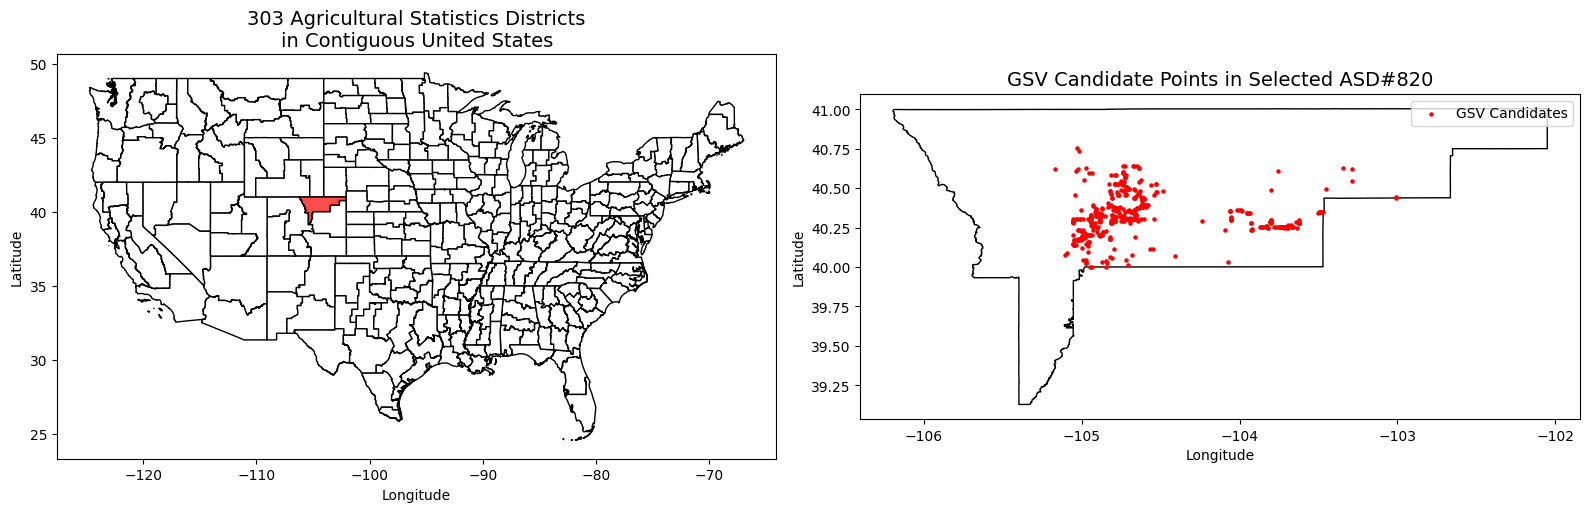

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# --- Plot 1: All ASDs and selected ASDs highlighted ---
# Plot all ASD polygons
ASD.plot(ax=axes[0], edgecolor='black', facecolor='white')

# Overlay selected ASDs
ASD_to_sample.plot(ax=axes[0], edgecolor='black', facecolor='red', alpha=0.7)

# Titles and labels
axes[0].set_title(f'{len(ASD)} Agricultural Statistics Districts\nin Contiguous United States', fontsize=14)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# --- Plot 2: Selected ASD with GSV points ---
# Plot selected ASD
ASD_to_sample.plot(ax=axes[1], edgecolor='black', facecolor='white')

# Overlay GSV candidate points
gsv_to_sample_gdf.plot(ax=axes[1], color='red', markersize=5, label='GSV Candidates')

# Titles and labels
axes[1].set_title('GSV Candidate Points in Selected ASD#820', fontsize=14)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

# Add legend to the second plot
axes[1].legend()

# Layout adjustment and display
plt.tight_layout()
plt.show()

In [44]:
fishnet_path = 'SET YOUR OWN PATH TO STORE THE GENERATED FISHNET GRIDS SHP'

We are "squeezing" the upper and bottom limits to get the final grids for sampling - one grid one GSV point in the most ideal conditions.

In [48]:
monotonic_closest(fishnetMaker,ASD_to_sample,fishnet_path,gsv_to_sample_gdf,target=target_size, integral=False)
fishnet_polygons = gpd.GeoDataFrame.from_file(fishnet_path)

At grid size = 0.005, we have polygons 361 with points
0.005
At grid size = 0.0025, we have polygons 396 with points
0.0025
At grid size = 0.00125, we have polygons 428 with points
0.00125
At grid size = 1, we have polygons 5 with points
At grid size = 0.500625, we have polygons 10 with points
At grid size = 0.2509375, we have polygons 22 with points
At grid size = 0.12609374999999998, we have polygons 47 with points
At grid size = 0.06367187499999999, we have polygons 90 with points
At grid size = 0.032460937499999995, we have polygons 158 with points
At grid size = 0.016855468749999998, we have polygons 231 with points
At grid size = 0.009052734375, we have polygons 299 with points
At grid size = 0.0051513671874999995, we have polygons 340 with points
At grid size = 0.00320068359375, we have polygons 374 with points
At grid size = 0.002225341796875, we have polygons 405 with points
At grid size = 0.0017376708984375, we have polygons 416 with points
At grid size = 0.00198150634765625,